# Descriptive Analysis

This notebook provides a structured descriptive overview of the main variables used in the study and examines their variation across Romanian counties and over time.

Main steps:
- Summarize the structure and coverage of the county-level panel dataset
- Generate descriptive statistics for the main analytical variables
- Examine county-level differences in agricultural employment, migration, and mechanization
- Compare counties using both mechanization measures
- Analyze temporal trends in agricultural employment, emigration, and machinery density
- Identify top and bottom counties for selected indicators
- Generate publication-ready tables and figures for the descriptive analysis

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("../../data/processed/analysis_dataset_eurostat.csv")
df.head(2)

,an,judet,emig_masc_nr,emig_fem_nr,emigranti_total_nr,emig_15_64_nr,imig_masc_nr,imig_fem_nr,imigranti_total_nr,imigranti_15_64_nr,...,migratie_neta_15_64_nr,rata_migratie_neta_15_64,ocupati_aff_eurostat_mii,ocupati_total_eurostat_mii,ocupati_aff_eurostat_nr,ocupati_total_eurostat_nr,pondere_ocupati_aff_eurostat,schimbare_pondere_ocupati_aff_eurostat,schimbare_ocupati_aff_eurostat_pct,ocupati_aff_eurostat_thousand
0,2012,Alba,143,144,287,222,43,33,76,66,...,-156,-0.679031,28.85,130.90,28850.0,130900.0,22.039725,NaN,NaN,28.85
1,2013,Alba,104,158,262,224,53,41,94,83,...,-141,-0.618020,30.38,131.94,30380.0,131940.0,23.025618,0.985893,5.303293,30.38


In [4]:
df.columns

Index(['an', 'judet', 'emig_masc_nr', 'emig_fem_nr', 'emigranti_total_nr',
       'emig_15_64_nr', 'imig_masc_nr', 'imig_fem_nr', 'imigranti_total_nr',
       'imigranti_15_64_nr', 'populatie_15_64', 'populatie_rurala',
       'populatie_totala', 'pondere_rurala', 'rata_emig_def', 'rata_imig_def',
       'rata_emig_15_64', 'rata_imig_15_64', 'intensitate_migratie',
       'sup_grau_ha', 'sup_orz_orzoaica_ha', 'sup_porumb_boabe_ha',
       'sup_floarea_soarelui_ha', 'sup_rapita_ha', 'sup_soia_boabe_ha',
       'sup_totala_cultivata_ha', 'pondere_grau', 'pondere_orz_orzoaica',
       'pondere_porumb_boabe', 'pondere_floarea_soarelui', 'pondere_rapita',
       'pondere_soia_boabe', 'prod_grau_tone', 'prod_orz_orzoaica_tone',
       'prod_porumb_boabe_tone', 'prod_floarea_soarelui_tone',
       'prod_rapita_tone', 'prod_soia_boabe_tone', 'yield_grau',
       'yield_orz_orzoaica', 'yield_porumb_boabe', 'yield_floarea_soarelui',
       'yield_rapita', 'yield_soia_boabe', 'ocupati_total_nr',


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Working copy
df_desc = df.copy()

# Panel identifiers
id_cols = ["judet", "an"]

# Main variables for the descriptive analysis
main_vars = [
    # Migration
    "rata_emig_15_64",
    "rata_imig_15_64",
    "rata_migratie_neta_15_64",
    "intensitate_migratie",

    # Agricultural labour
    "pondere_ocupati_aff_eurostat",
    "schimbare_pondere_ocupati_aff_eurostat",

    # Mechanization
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",

    # Agricultural productivity
    "yield_grau",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",

    # Climate
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",

    # Agricultural structure
    "sup_totala_cultivata_ha",
    "pondere_grau",
    "pondere_porumb_boabe",
    "pondere_floarea_soarelui"
]

# Keep only variables that exist in the dataframe
main_vars = [v for v in main_vars if v in df_desc.columns]

# English labels for display
pretty_names = {
    # Identifiers
    "judet": "County",
    "an": "Year",
    

    # Migration
    "rata_emig_15_64": "Emigration rate, age group 15–64",
    "rata_imig_15_64": "Immigration rate, age group 15–64",
    "rata_migratie_neta_15_64": "Net migration rate, age group 15–64",
    "intensitate_migratie": "Migration intensity",

    # Agricultural labour
    "pondere_ocupati_aff_eurostat": "Share of employment in agriculture",
    "schimbare_pondere_ocupati_aff_eurostat": "Annual change in agricultural employment share",

    # Mechanization
    "indice_mecanizare_densitate": "Mechanization density index",
    "indice_mecanizare_rezidual": "Residual mechanization index",

    # Productivity
    "yield_grau": "Wheat yield",
    "yield_porumb_boabe": "Maize yield",
    "yield_floarea_soarelui": "Sunflower yield",

    # Climate
    "temperatura_medie_anuala_C": "Average annual temperature (°C)",
    "precipitatii_anuale_mm": "Annual precipitation (mm)",

    # Agricultural structure
    "sup_totala_cultivata_ha": "Total cultivated area (ha)",
    "pondere_grau": "Share of wheat area",
    "pondere_porumb_boabe": "Share of maize area",
    "pondere_floarea_soarelui": "Share of sunflower area"
}

def label_var(var):
    return pretty_names.get(var, var)

print("Main variables selected for the descriptive analysis:")
for var in main_vars:
    print(f"- {label_var(var)}")

Main variables selected for the descriptive analysis:
- Emigration rate, age group 15–64
- Immigration rate, age group 15–64
- Net migration rate, age group 15–64
- Migration intensity
- Share of employment in agriculture
- Annual change in agricultural employment share
- Mechanization density index
- Residual mechanization index
- Wheat yield
- Maize yield
- Sunflower yield
- Average annual temperature (°C)
- Annual precipitation (mm)
- Total cultivated area (ha)
- Share of wheat area
- Share of maize area
- Share of sunflower area


### 1. Dataset Structure

In [6]:
# Basic panel structure
n_counties = df_desc["judet"].nunique()
n_years = df_desc["an"].nunique()
years = sorted(df_desc["an"].dropna().unique())

panel_summary = pd.DataFrame({
    "Indicator": [
        "Number of counties",
        "Number of years",
        "First year",
        "Last year",
        "Existing county-year observations",
        "Theoretical county-year observations"
    ],
    "Value": [
        n_counties,
        n_years,
        min(years),
        max(years),
        len(df_desc),
        n_counties * n_years
    ]
})

display(panel_summary)

# Duplicate county-year observations
duplicates = df_desc[df_desc.duplicated(subset=["judet", "an"], keep=False)]

print(f"Number of duplicate county-year observations: {len(duplicates)}")

if len(duplicates) > 0:
    display(
        duplicates
        .sort_values(["judet", "an"])
        .rename(columns=pretty_names)
    )

# Number of years available by county
panel_balance = (
    df_desc
    .groupby("judet")["an"]
    .nunique()
    .reset_index(name="Number of available years")
    .rename(columns={"judet": "County"})
    .sort_values("Number of available years")
)

display(panel_balance)

# Missing values for main variables
missing_table = pd.DataFrame({
    "Variable": [label_var(v) for v in main_vars],
    "Technical name": main_vars,
    "Total N": len(df_desc),
    "Valid N": [df_desc[v].notna().sum() for v in main_vars],
    "Missing N": [df_desc[v].isna().sum() for v in main_vars],
    "Missing (%)": [df_desc[v].isna().mean() * 100 for v in main_vars]
})

missing_table = missing_table.sort_values("Missing (%)", ascending=False)

display(missing_table.round(2))

,Indicator,Value
0,Number of counties,41
1,Number of years,11
2,First year,2012
3,Last year,2022
4,Existing county-year observations,451
5,Theoretical county-year observations,451


Number of duplicate county-year observations: 0


,County,Number of available years
0,Alba,11
1,Arad,11
2,Arges,11
3,Bacau,11
4,Bihor,11
5,Bistrita-Nasaud,11
6,Botosani,11
7,Braila,11
8,Brasov,11
9,Buzau,11


,Variable,Technical name,Total N,Valid N,Missing N,Missing (%)
5,Annual change in agricultural employment share,schimbare_pondere_ocupati_aff_eurostat,451,410,41,9.09
10,Sunflower yield,yield_floarea_soarelui,451,437,14,3.10
0,"Emigration rate, age group 15–64",rata_emig_15_64,451,451,0,0.00
3,Migration intensity,intensitate_migratie,451,451,0,0.00
1,"Immigration rate, age group 15–64",rata_imig_15_64,451,451,0,0.00
4,Share of employment in agriculture,pondere_ocupati_aff_eurostat,451,451,0,0.00
6,Mechanization density index,indice_mecanizare_densitate,451,451,0,0.00
7,Residual mechanization index,indice_mecanizare_rezidual,451,451,0,0.00
2,"Net migration rate, age group 15–64",rata_migratie_neta_15_64,451,451,0,0.00
8,Wheat yield,yield_grau,451,451,0,0.00


### 2. Missing values

In [7]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Create clean missing values table
missing_values_table = pd.DataFrame({
    "Variable": [pretty_names.get(v, v) for v in main_vars],
    "Valid observations": [df_desc[v].notna().sum() for v in main_vars],
    "Missing observations": [df_desc[v].isna().sum() for v in main_vars],
    "Missing values (%)": [df_desc[v].isna().mean() * 100 for v in main_vars]
})

# Round percentages
missing_values_table["Missing values (%)"] = missing_values_table["Missing values (%)"].round(2)

# Sort by percentage of missing values
missing_values_table = missing_values_table.sort_values(
    "Missing values (%)", 
    ascending=False
).reset_index(drop=True)

# Display table
display(missing_values_table)


,Variable,Valid observations,Missing observations,Missing values (%)
0,Annual change in agricultural employment share,410,41,9.09
1,Sunflower yield,437,14,3.10
2,"Emigration rate, age group 15–64",451,0,0.00
3,Migration intensity,451,0,0.00
4,"Immigration rate, age group 15–64",451,0,0.00
5,Share of employment in agriculture,451,0,0.00
6,Mechanization density index,451,0,0.00
7,Residual mechanization index,451,0,0.00
8,"Net migration rate, age group 15–64",451,0,0.00
9,Wheat yield,451,0,0.00


In [10]:
missing_values_table = pd.DataFrame({
    "Variable": [pretty_names.get(v, v) for v in main_vars],
    "Valid N": [df_desc[v].notna().sum() for v in main_vars],
    "Missing N": [df_desc[v].isna().sum() for v in main_vars],
    "Missing (%)": [df_desc[v].isna().mean() * 100 for v in main_vars]
})

missing_values_table["Missing (%)"] = missing_values_table["Missing (%)"].round(2)

# Sort by highest percentage of missing values
missing_values_table = (
    missing_values_table
    .sort_values("Missing (%)", ascending=False)
    .reset_index(drop=True)
)

# Show the table in notebook
display(missing_values_table)



,Variable,Valid N,Missing N,Missing (%)
0,Annual change in agricultural employment share,410,41,9.09
1,Sunflower yield,437,14,3.10
2,"Emigration rate, age group 15–64",451,0,0.00
3,Migration intensity,451,0,0.00
4,"Immigration rate, age group 15–64",451,0,0.00
5,Share of employment in agriculture,451,0,0.00
6,Mechanization density index,451,0,0.00
7,Residual mechanization index,451,0,0.00
8,"Net migration rate, age group 15–64",451,0,0.00
9,Wheat yield,451,0,0.00


### 3. Descriptive Statistics

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Build descriptive statistics table
# Uses existing: df_desc, main_vars, pretty_names
# -----------------------------

descriptive_stats_table = []

for var in main_vars:
    x = df_desc[var]

    descriptive_stats_table.append({
        "Variable": pretty_names.get(var, var),
        "N": x.notna().sum(),
        "Mean": x.mean(),
        "Median": x.median(),
        "Std. dev.": x.std(ddof=1),
        "Min": x.min(),
        "P25": x.quantile(0.25),
        "P75": x.quantile(0.75),
        "Max": x.max()
    })

descriptive_stats_table = pd.DataFrame(descriptive_stats_table)

# Round numeric columns
numeric_cols = descriptive_stats_table.select_dtypes(include="number").columns
descriptive_stats_table[numeric_cols] = descriptive_stats_table[numeric_cols].round(3)

display(descriptive_stats_table)


,Variable,N,Mean,Median,Std. dev.,Min,P25,P75,Max
0,"Emigration rate, age group 15–64",451,1.376,1.109,0.961,0.153,0.767,1.748,8.307
1,"Immigration rate, age group 15–64",451,2.141,0.472,5.531,0.072,0.301,0.911,46.459
2,"Net migration rate, age group 15–64",451,0.764,-0.532,5.218,-3.941,-0.961,-0.200,43.394
3,Migration intensity,451,2.645,1.366,4.283,0.284,0.898,2.231,35.844
4,Share of employment in agriculture,451,28.612,26.849,15.815,2.730,14.528,41.542,66.145
5,Annual change in agricultural employment share,410,-1.004,-0.900,2.511,-13.004,-2.255,0.464,8.568
6,Mechanization density index,451,0.000,-0.355,0.931,-0.981,-0.684,0.327,3.856
7,Residual mechanization index,451,-0.000,0.061,0.908,-2.531,-0.646,0.674,2.082
8,Wheat yield,451,3.775,3.778,0.884,0.983,3.195,4.402,5.995
9,Maize yield,451,4.631,4.476,1.720,0.252,3.466,5.787,10.421


### 4. Data Coverage

In [12]:

# -----------------------------
# Basic panel information
# -----------------------------
id_county = "judet"
id_year = "an"

n_counties = df_desc[id_county].nunique()
n_years = df_desc[id_year].nunique()

years = sorted(df_desc[id_year].dropna().unique())
first_year = min(years)
last_year = max(years)

existing_observations = len(df_desc)
theoretical_observations = n_counties * n_years

duplicates = df_desc.duplicated(subset=[id_county, id_year], keep=False).sum()

# Check whether each county has the same number of years
years_per_county = df_desc.groupby(id_county)[id_year].nunique()
min_years_per_county = years_per_county.min()
max_years_per_county = years_per_county.max()



coverage_rate = existing_observations / theoretical_observations * 100

# -----------------------------
# Build panel structure table
# -----------------------------
panel_structure_table = pd.DataFrame({
    "Indicator": [
        "Number of counties",
        "Number of years",
        "Period covered",
        "Existing county-year observations",
        "Coverage rate (%)",
        "Duplicate county-year observations",
    ],
    "Value": [
        n_counties,
        n_years,
        f"{first_year}–{last_year}",
        existing_observations,
        round(coverage_rate, 2),
        duplicates
    ]
})

display(panel_structure_table)


,Indicator,Value
0,Number of counties,41
1,Number of years,11
2,Period covered,2012–2022
3,Existing county-year observations,451
4,Coverage rate (%),100.0
5,Duplicate county-year observations,0


### 5. Top and Bottom Counties by Average Machinery Density Index

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1.mechanization variable
# -----------------------------
mech_col = "indice_mecanizare_rezidual"

# -----------------------------
#2.compute county-level average residual mechanization
# -----------------------------
county_mechanization = (
    df_desc
    .groupby("judet")[mech_col]
    .mean()
    .reset_index()
    .sort_values(mech_col, ascending=False)
)

# -----------------------------
# 3.create top and bottom table
# -----------------------------
top_10 = county_mechanization.head(10).copy()
bottom_10 = county_mechanization.tail(10).copy().sort_values(mech_col, ascending=True)

top_10["Group"] = "Top 10"
bottom_10["Group"] = "Bottom 10"

mechanization_heterogeneity_table = pd.concat([top_10, bottom_10], axis=0)

mechanization_heterogeneity_table = mechanization_heterogeneity_table.rename(columns={
    "judet": "County",
    mech_col: "Average residual mechanization index"
})

mechanization_heterogeneity_table = mechanization_heterogeneity_table[
    ["Group", "County", "Average residual mechanization index"]
]

mechanization_heterogeneity_table["Average residual mechanization index"] = (
    mechanization_heterogeneity_table["Average residual mechanization index"].round(3)
)

display(mechanization_heterogeneity_table)

,Group,County,Average residual mechanization index
4,Top 10,Bihor,1.798
36,Top 10,Timis,1.167
27,Top 10,Mures,1.157
16,Top 10,Dolj,1.111
29,Top 10,Olt,1.092
1,Top 10,Arad,0.949
32,Top 10,Satu Mare,0.905
25,Top 10,Maramures,0.875
35,Top 10,Teleorman,0.782
15,Top 10,Dambovita,0.627


In [ ]:

mech_col = "indice_mecanizare_densitate"

county_mechanization = (
    df_desc
    .groupby("judet")[mech_col]
    .mean()
    .reset_index()
    .sort_values(mech_col, ascending=False)
)

#create table
top_10 = county_mechanization.head(10).copy()
bottom_10 = county_mechanization.tail(10).copy().sort_values(mech_col, ascending=True)

top_10["Group"] = "Top 10"
bottom_10["Group"] = "Bottom 10"

mechanization_heterogeneity_table = pd.concat([top_10, bottom_10], axis=0)

mechanization_heterogeneity_table = mechanization_heterogeneity_table.rename(columns={
    "judet": "County",
    mech_col: "Average mechanization density index"
})

mechanization_heterogeneity_table = mechanization_heterogeneity_table[
    ["Group", "County", "Average mechanization density index"]
]

mechanization_heterogeneity_table["Average mechanization density index"] = (
    mechanization_heterogeneity_table["Average mechanization density index"].round(3)
)

display(mechanization_heterogeneity_table)

,Group,County,Average mechanization density index
25,Top 10,Maramures,2.921
20,Top 10,Harghita,2.189
21,Top 10,Hunedoara,1.738
8,Top 10,Brasov,1.730
31,Top 10,Salaj,1.342
33,Top 10,Sibiu,0.938
11,Top 10,Caras-Severin,0.929
14,Top 10,Covasna,0.650
5,Top 10,Bistrita-Nasaud,0.378
12,Top 10,Cluj,0.361


,Year,Average share of employment in agriculture
0,2012,34.885
1,2013,34.563
2,2014,33.459
3,2015,29.941
4,2016,27.299
5,2017,26.798
6,2018,26.689
7,2019,25.739
8,2020,25.030
9,2021,25.495


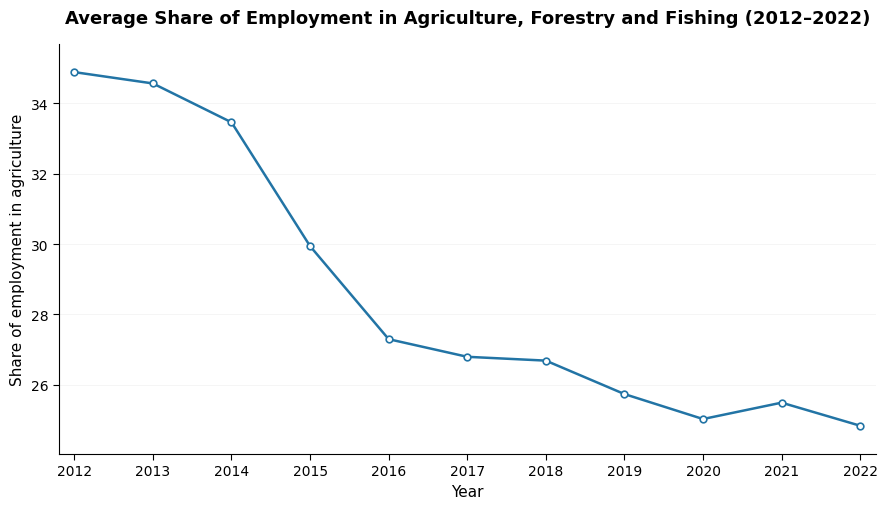

Image saved as: annual_trend_agricultural_employment_share.png


In [16]:

aff_col = "pondere_ocupati_aff_eurostat"

#annual average

annual_aff = (
    df_desc
    .groupby("an")[aff_col]
    .mean()
    .reset_index()
    .sort_values("an")
)

# Optional display table
annual_aff_display = annual_aff.copy()
annual_aff_display.columns = ["Year", "Average share of employment in agriculture"]
annual_aff_display["Average share of employment in agriculture"] = (
    annual_aff_display["Average share of employment in agriculture"].round(3)
)

display(annual_aff_display)

# -----------------------------
# 3. create plot
# -----------------------------
line_color = "#2274A5"

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    annual_aff["an"],
    annual_aff[aff_col],
    color=line_color,
    linewidth=1.8,
    marker="o",
    markersize=4.8,
    markerfacecolor="white",
    markeredgecolor=line_color,
    markeredgewidth=1.2
)

ax.set_title(
    "Average Share of Employment in Agriculture, Forestry and Fishing (2012–2022)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

# Axis labels
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Share of employment in agriculture", fontsize=11)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Subtle horizontal grid only
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.18)
ax.xaxis.grid(False)


ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)


ax.set_xticks(annual_aff["an"])

ax.margins(x=0.02, y=0.08)

plt.tight_layout()

# Save as PNG
output_file = "annual_trend_agricultural_employment_share.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

,Year,"Average tractors per 1,000 ha"
0,2012,55.401
1,2013,57.900
2,2014,58.262
3,2015,61.660
4,2016,62.413
5,2017,69.494
6,2018,68.327
7,2019,70.863
8,2020,77.746
9,2021,81.966


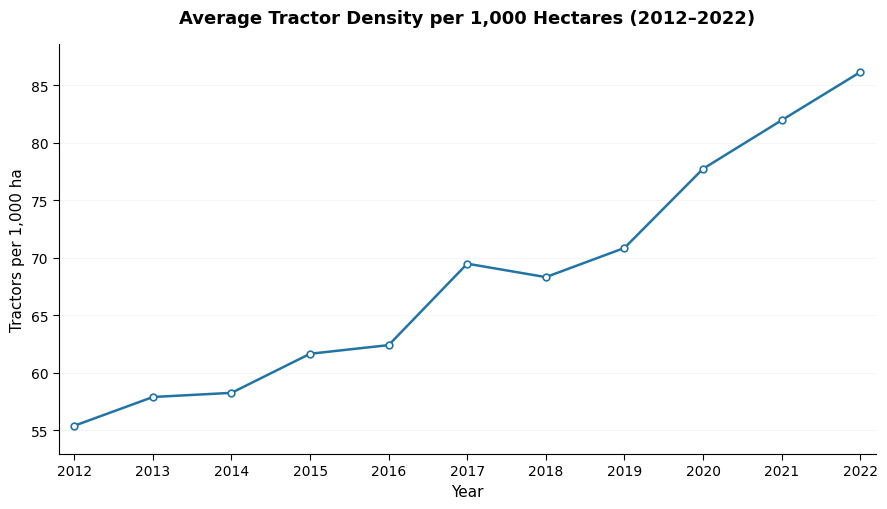

Image saved as: annual_trend_tractors_per_1000ha.png


In [17]:
#variable
tractor_col = "tractoare_1000ha"

#annual average
annual_tractors = (
    df_desc
    .groupby("an")[tractor_col]
    .mean()
    .reset_index()
    .sort_values("an")
)

# Optional display table
annual_tractors_display = annual_tractors.copy()
annual_tractors_display.columns = ["Year", "Average tractors per 1,000 ha"]
annual_tractors_display["Average tractors per 1,000 ha"] = (
    annual_tractors_display["Average tractors per 1,000 ha"].round(3)
)

display(annual_tractors_display)

# -----------------------------
#create plot
# -----------------------------
line_color = "#2274A5"

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    annual_tractors["an"],
    annual_tractors[tractor_col],
    color=line_color,
    linewidth=1.8,
    marker="o",
    markersize=4.8,
    markerfacecolor="white",
    markeredgecolor=line_color,
    markeredgewidth=1.2
)

ax.set_title(
    "Average Tractor Density per 1,000 Hectares (2012–2022)",
    fontsize=13,
    fontweight="bold",
    pad=15
)

# Axis labels
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Tractors per 1,000 ha", fontsize=11)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Subtle horizontal grid only
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.18)
ax.xaxis.grid(False)

# Ticks
ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)

# Show every year
ax.set_xticks(annual_tractors["an"])

# Slight margins
ax.margins(x=0.02, y=0.08)

plt.tight_layout()

# Save as PNG
output_file = "annual_trend_tractors_per_1000ha.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

,Year,"Average emigration rate, age group 15–64"
0,2012,0.745
1,2013,0.836
2,2014,0.670
3,2015,0.870
4,2016,1.345
5,2017,1.319
6,2018,1.578
7,2019,1.594
8,2020,1.262
9,2021,2.034


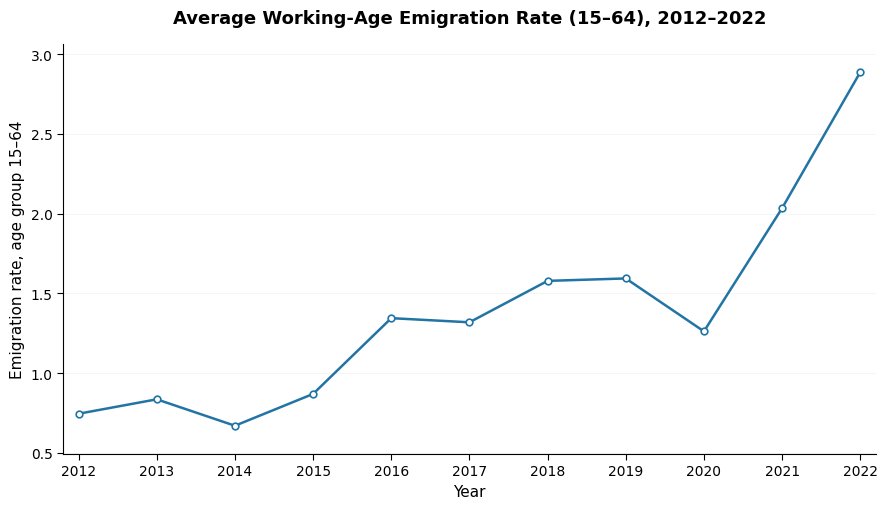

Image saved as: annual_trend_emigration_rate_15_64.png


In [18]:
#variable
emig_col = "rata_emig_15_64"

#annual average
annual_emigration = (
    df_desc
    .groupby("an")[emig_col]
    .mean()
    .reset_index()
    .sort_values("an")
)

# Optional display table
annual_emigration_display = annual_emigration.copy()
annual_emigration_display.columns = ["Year", "Average emigration rate, age group 15–64"]
annual_emigration_display["Average emigration rate, age group 15–64"] = (
    annual_emigration_display["Average emigration rate, age group 15–64"].round(3)
)

display(annual_emigration_display)


#plot
line_color = "#2274A5"

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    annual_emigration["an"],
    annual_emigration[emig_col],
    color=line_color,
    linewidth=1.8,
    marker="o",
    markersize=4.8,
    markerfacecolor="white",
    markeredgecolor=line_color,
    markeredgewidth=1.2
)

# No title inside image
ax.set_title(
    "Average Working-Age Emigration Rate (15–64), 2012–2022",
    fontsize=13,
    fontweight="bold",
    pad=15
)

# Axis labels
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Emigration rate, age group 15–64", fontsize=11)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

# Subtle horizontal grid only
ax.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.18)
ax.xaxis.grid(False)

# Ticks
ax.tick_params(axis="both", labelsize=10, length=4, width=0.8)

# Show every year
ax.set_xticks(annual_emigration["an"])

# Slight margins
ax.margins(x=0.02, y=0.08)

plt.tight_layout()

# Save as PNG
output_file = "annual_trend_emigration_rate_15_64.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Image saved as: {output_file}")

### 6. Top and Bottom 5 Counties by Average Share of Employment in Agriculture, Forestry and Fishing

In [19]:
#variable

aff_col = "pondere_ocupati_aff_eurostat"

# -----------------------------
#county-level average
# -----------------------------
county_aff = (
    df_desc
    .groupby("judet")[aff_col]
    .mean()
    .reset_index()
    .sort_values(aff_col, ascending=False)
)

# -----------------------------
#create tables
# -----------------------------
top_5 = county_aff.head(5).copy()
bottom_5 = county_aff.tail(5).copy().sort_values(aff_col, ascending=True)

top_5["Rank"] = range(1, 6)
bottom_5["Rank"] = range(1, 6)

top_5 = top_5.rename(columns={
    "judet": "County",
    aff_col: "Average share of employment in agriculture"
})

bottom_5 = bottom_5.rename(columns={
    "judet": "County",
    aff_col: "Average share of employment in agriculture"
})

top_5 = top_5[["Rank", "County", "Average share of employment in agriculture"]]
bottom_5 = bottom_5[["Rank", "County", "Average share of employment in agriculture"]]

top_5["Average share of employment in agriculture"] = (
    top_5["Average share of employment in agriculture"].round(3)
)

bottom_5["Average share of employment in agriculture"] = (
    bottom_5["Average share of employment in agriculture"].round(3)
)

display(top_5)
display(bottom_5)


,Rank,County,Average share of employment in agriculture
39,1,Vaslui,61.744
22,2,Ialomita,53.862
28,3,Neamt,52.923
10,4,Calarasi,50.294
29,5,Olt,48.060


,Rank,County,Average share of employment in agriculture
24,1,Ilfov,4.877
33,2,Sibiu,8.075
21,3,Hunedoara,10.624
36,4,Timis,10.645
27,5,Mures,10.695


### 7. Top and Bottom 5 Counties by Average Residual Mechanization Index

In [21]:
#  variable
mech_col = "indice_mecanizare_rezidual"

# -----------------------------
# county-level average
# -----------------------------
county_mech = (
    df_desc
    .groupby("judet")[mech_col]
    .mean()
    .reset_index()
    .sort_values(mech_col, ascending=False)
)

# -----------------------------
# create tables
# -----------------------------
top_5_mech = county_mech.head(5).copy()
bottom_5_mech = county_mech.tail(5).copy().sort_values(mech_col, ascending=True)

top_5_mech["Rank"] = range(1, 6)
bottom_5_mech["Rank"] = range(1, 6)

top_5_mech = top_5_mech.rename(columns={
    "judet": "County",
    mech_col: "Average residual mechanization index"
})

bottom_5_mech = bottom_5_mech.rename(columns={
    "judet": "County",
    mech_col: "Average residual mechanization index"
})

top_5_mech = top_5_mech[["Rank", "County", "Average residual mechanization index"]]
bottom_5_mech = bottom_5_mech[["Rank", "County", "Average residual mechanization index"]]

top_5_mech["Average residual mechanization index"] = (
    top_5_mech["Average residual mechanization index"].round(3)
)

bottom_5_mech["Average residual mechanization index"] = (
    bottom_5_mech["Average residual mechanization index"].round(3)
)

display(top_5_mech)
display(bottom_5_mech)


,Rank,County,Average residual mechanization index
4,1,Bihor,1.798
36,2,Timis,1.167
27,3,Mures,1.157
16,4,Dolj,1.111
29,5,Olt,1.092


,Rank,County,Average residual mechanization index
24,1,Ilfov,-1.886
30,2,Prahova,-1.732
37,3,Tulcea,-1.271
9,4,Buzau,-1.165
7,5,Braila,-1.162


### 8. Top and Bottom 5 Counties by Average Working-Age Emigration Rate (15–64)

In [22]:
# variable

emig_col = "rata_emig_15_64"

# -----------------------------
# county-level average
# -----------------------------
county_emig = (
    df_desc
    .groupby("judet")[emig_col]
    .mean()
    .reset_index()
    .sort_values(emig_col, ascending=False)
)

# -----------------------------
# create tables
# -----------------------------
top_5_emig = county_emig.head(5).copy()
bottom_5_emig = county_emig.tail(5).copy().sort_values(emig_col, ascending=True)

top_5_emig["Rank"] = range(1, 6)
bottom_5_emig["Rank"] = range(1, 6)

top_5_emig = top_5_emig.rename(columns={
    "judet": "County",
    emig_col: "Average emigration rate, age group 15–64"
})

bottom_5_emig = bottom_5_emig.rename(columns={
    "judet": "County",
    emig_col: "Average emigration rate, age group 15–64"
})

top_5_emig = top_5_emig[["Rank", "County", "Average emigration rate, age group 15–64"]]
bottom_5_emig = bottom_5_emig[["Rank", "County", "Average emigration rate, age group 15–64"]]

top_5_emig["Average emigration rate, age group 15–64"] = (
    top_5_emig["Average emigration rate, age group 15–64"].round(3)
)

bottom_5_emig["Average emigration rate, age group 15–64"] = (
    bottom_5_emig["Average emigration rate, age group 15–64"].round(3)
)

display(top_5_emig)
display(bottom_5_emig)


,Rank,County,"Average emigration rate, age group 15–64"
39,1,Vaslui,2.646
23,2,Iasi,2.628
11,3,Caras-Severin,2.462
17,4,Galati,2.386
33,5,Sibiu,2.190


,Rank,County,"Average emigration rate, age group 15–64"
20,1,Harghita,0.509
24,2,Ilfov,0.613
19,3,Gorj,0.622
14,4,Covasna,0.626
4,5,Bihor,0.782


### 9. Top and Bottom 5 Counties by Average Tractor Density (per 1,000 ha)

In [23]:
# variable
tractor_col = "tractoare_1000ha"

# -----------------------------
# county-level average
# -----------------------------
county_tractors = (
    df_desc
    .groupby("judet")[tractor_col]
    .mean()
    .reset_index()
    .sort_values(tractor_col, ascending=False)
)

# -----------------------------
# create tables
# -----------------------------
top_5_tractors = county_tractors.head(5).copy()
bottom_5_tractors = county_tractors.tail(5).copy().sort_values(tractor_col, ascending=True)

top_5_tractors["Rank"] = range(1, 6)
bottom_5_tractors["Rank"] = range(1, 6)

top_5_tractors = top_5_tractors.rename(columns={
    "judet": "County",
    tractor_col: "Average tractors per 1,000 ha"
})

bottom_5_tractors = bottom_5_tractors.rename(columns={
    "judet": "County",
    tractor_col: "Average tractors per 1,000 ha"
})

top_5_tractors = top_5_tractors[["Rank", "County", "Average tractors per 1,000 ha"]]
bottom_5_tractors = bottom_5_tractors[["Rank", "County", "Average tractors per 1,000 ha"]]

top_5_tractors["Average tractors per 1,000 ha"] = (
    top_5_tractors["Average tractors per 1,000 ha"].round(3)
)

bottom_5_tractors["Average tractors per 1,000 ha"] = (
    bottom_5_tractors["Average tractors per 1,000 ha"].round(3)
)

display(top_5_tractors)
display(bottom_5_tractors)


,Rank,County,"Average tractors per 1,000 ha"
25,1,Maramures,397.600
20,2,Harghita,244.610
21,3,Hunedoara,210.638
8,4,Brasov,165.409
31,5,Salaj,155.809


,Rank,County,"Average tractors per 1,000 ha"
7,1,Braila,8.294
13,2,Constanta,8.434
22,3,Ialomita,11.941
37,4,Tulcea,12.776
9,5,Buzau,12.908


## Key Findings

- Agricultural employment declined over the 2012–2022 period, while working-age emigration generally increased.
- Mechanization increased over time, particularly in terms of tractor density, although substantial differences remain across counties.
- Counties differ considerably in their agricultural employment structure, migration patterns, and level of mechanization.
- The machinery density and residual mechanization indices produce different county rankings, highlighting the importance of accounting for differences in cultivated area.
- The descriptive results suggest substantial territorial heterogeneity, motivating the use of county and year fixed-effects models in the subsequent analysis.